In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Pour reproduire les résultats
np.random.seed(42)
tf.random.set_seed(42)

## Q1) Chargement des données

In [ ]:
# Charger le dataset
df = pd.read_csv('dataset_fraude.csv')

print("Dimensions du dataset :", df.shape)
print(f"  → {df.shape[0]} transactions, {df.shape[1]} variables\n")
df.head()

Dimensions du dataset : (5228, 11)
  → 5228 transactions, 11 variables



,amount,hour,merchant_category,country,country_risk,distance_km,tx_last_1h,tx_last_24h,device_change,is_international,label_fraud
0,11.95,12,online_services,MA,0.044,13.91,4,8,0,0,1
1,10.29,11,utilities,MA,0.136,13.17,1,4,0,0,0
2,97.04,19,pharmacy,MA,0.075,51.35,0,2,0,0,0
3,16.60,19,atm,MA,0.047,21.52,3,7,0,0,0
4,70.93,7,fuel,CN,0.396,47.09,0,2,0,1,0


## Q2 – Analyse de la variable cible

In [ ]:
# Avec value_counts()
print("=== Distribution de label_fraud ===")
print(df['label_fraud'].value_counts())


=== Distribution de label_fraud ===
label_fraud
0    4451
1     777
Name: count, dtype: int64


## Q3 – Séparation des variables

In [ ]:
# Variables explicatives (features) et variable cible
X = df.drop(columns=['label_fraud'])
y = df['label_fraud']

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (5228, 10)
Dimensions de y : (5228,)


## Q4 – Encodage des variables catégorielles

In [ ]:
# Variables catégorielles : merchant_category et country
print("Valeurs uniques de merchant_category :", X['merchant_category'].unique())
print("Valeurs uniques de country :", X['country'].unique())

# One-Hot Encoding
X = pd.get_dummies(X, columns=['merchant_category', 'country'], drop_first=False,dtype = int)

# cols_bool = X.select_dtypes(include="bool").columns
# X[cols_bool] = X[cols_bool].astype(int)


print("\nNouvelle dimension de X après encodage :", X.shape)
print("Dimensions de y :", y.shape)

X.head()


Valeurs uniques de merchant_category : ['online_services' 'utilities' 'pharmacy' 'atm' 'fuel' 'restaurant'
 'travel' 'grocery' 'electronics' 'other' 'fashion' 'gaming']
Valeurs uniques de country : ['MA' 'CN' 'UK' 'AE' 'FR' 'ES' 'NG' 'RU' 'US' 'BR']

Nouvelle dimension de X après encodage : (5228, 30)
Dimensions de y : (5228,)


,amount,hour,country_risk,distance_km,tx_last_1h,tx_last_24h,device_change,is_international,merchant_category_atm,merchant_category_electronics,...,country_AE,country_BR,country_CN,country_ES,country_FR,country_MA,country_NG,country_RU,country_UK,country_US
0,11.95,12,0.044,13.91,4,8,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,10.29,11,0.136,13.17,1,4,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,97.04,19,0.075,51.35,0,2,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,16.60,19,0.047,21.52,3,7,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,70.93,7,0.396,47.09,0,2,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0


## Q5 – Split des données (70% train / 15% val / 15% test)

In [ ]:
# 1ère division : 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2ème division : 50% val, 50% test (15% chacun du total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train      : {X_train.shape[0]} exemples")
print(f"Validation : {X_val.shape[0]} exemples")
print(f"Test       : {X_test.shape[0]} exemples")
# ici on calcul moyenne des 1 qui represent la class fraude
print(f"\nTaux de fraude – Train : {y_train.mean():.3f} | Val : {y_val.mean():.3f} | Test : {y_test.mean():.3f}")

Train      : 3659 exemples
Validation : 784 exemples
Test       : 785 exemples

Taux de fraude – Train : 0.149 | Val : 0.148 | Test : 0.149


## Q6 – Mise à l'échelle (Standardisation)

In [ ]:
scaler = StandardScaler()
# knt kn tester 9bl mti7an print(X_train.info())
# ici fit_transform on ajuste UNIQUEMENT sur le train
X_train_sc = scaler.fit_transform(X_train)

# ici transform on applique la transformation sur val et test
X_val_sc  = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)
# print(X_train_sc.dtype)


## Q7 – Construction du modèle MLP

In [ ]:
n_features = X_train_sc.shape[1]
print(f"Nombre de variables d'entrée : {n_features}")

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.30),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.20),
    layers.Dense(1, activation='sigmoid')   # Sortie
])

model.summary()

Nombre de variables d'entrée : 30


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

## Q8 – Compilation du modèle


**Pourquoi le recall est-il une métrique importante dans la détection de fraude ?**

Dans la détection de fraude, **manquer une fraude (faux négatif) est bien plus coûteux** que générer une fausse alerte (faux positif). Le **recall**  mesure la proportion de fraudes réelles que le modèle a effectivement détectées : `Recall = TP / (TP + FN)`. Un recall élevé signifie que le modèle rate peu de fraudes, ce qui est l'objectif prioritaire d'un système de sécurité bancaire. L'accuracy seule est trompeuse sur des données déséquilibrées (un modèle qui prédit toujours « normal » aurait une accuracy élevée mais un recall nul).

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy', keras.metrics.Recall(name='recall')]
)
print("Modèle compilé avec succès.")

Modèle compilé avec succès.


## Q9) Gestion du surapprentissage

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Surveiller la loss de validation
    patience=5,               # Stopper après 5 epochs sans amélioration
    restore_best_weights=True # Restaurer les meilleurs poids
)
print("Callback EarlyStopping configuré.")

Callback EarlyStopping configuré.


## Q10) Gestion du déséquilibre des classes

In [ ]:
#10) class_weight
# donne plus de poids à la classe minoritaire (fraude)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
class_weight = {0: 1.0, 1: (neg / max(pos, 1))}
print("\nclass_weight:", class_weight)


class_weight: {0: 1.0, 1: 5.726102941176471}


## Q11) Entraînement du modèle

In [ ]:
history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=200,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1
)
print(f"\nEntraînement terminé à l'epoch {len(history.history['loss'])}")

Epoch 1/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4960 - loss: 1.1982 - recall: 0.6820 - val_accuracy: 0.6569 - val_loss: 0.6396 - val_recall: 0.6379
Epoch 2/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6007 - loss: 1.1301 - recall: 0.6103 - val_accuracy: 0.6429 - val_loss: 0.6398 - val_recall: 0.6983
Epoch 3/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6485 - loss: 1.0809 - recall: 0.6471 - val_accuracy: 0.6849 - val_loss: 0.5985 - val_recall: 0.5862
Epoch 4/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6576 - loss: 1.0768 - recall: 0.6250 - val_accuracy: 0.6875 - val_loss: 0.5918 - val_recall: 0.5776
Epoch 5/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6740 - loss: 1.0502 - recall: 0.6360 - val_accuracy: 0.6773 - val_loss: 0.5940 - val_recall: 0.5690
Epoch 6/200
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6709 - loss: 1.0563 - recall: 0.6268 - val_accuracy: 0.6684 - val_loss: 0.6016 - val_recall: 0.6034
Epoch 7/2

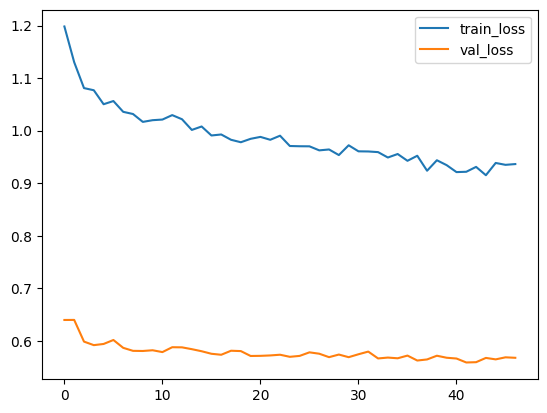

In [ ]:
plt.figure()
plt.plot(history.history["loss"],label="train_loss")
plt.plot(history.history["val_loss"],label="val_loss")
# plt.plot(history.history["accuracy"],label="train_accuracy")
# plt.plot(history.history["val_accuracy"],label="val_accuracy")
# plt.plot(history.history["recall"],label="train_recall")
# plt.plot(history.history["val_recall"],label="val_recall")
plt.legend()
plt.show()

## Q13) Évaluation du modèle

In [ ]:
# 13) Évaluation sur TEST
# Distribution des classes dans le test
print("\n--- Distribution des classes dans TEST ---")
print("Normal (0) :", (y_test == 0).sum())
print("Fraude (1) :", (y_test == 1).sum())

test_loss, test_acc, test_recall = model.evaluate(X_test_sc, y_test, verbose=0)
print(f"\nTEST → loss={test_loss:.4f} | acc={test_acc:.4f} | recall={test_recall:.4f}")

# Probabilités + prédictions
y_proba = model.predict(X_test_sc).ravel()
y_pred  = (y_proba >= 0.5).astype(int)

# Matrice de confusion
print("\n--- Confusion Matrix (seuil=0.5) ---")
cm = confusion_matrix(y_test, y_pred,labels=[1,0])
print(cm)

# Métriques
print("\n--- Metrics ---")
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1       :", f1_score(y_test, y_pred, zero_division=0))



--- Distribution des classes dans TEST ---
Normal (0) : 668
Fraude (1) : 117

TEST → loss=0.5567 | acc=0.7197 | recall=0.5214
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- Confusion Matrix (seuil=0.5) ---
[[ 61  56]
 [164 504]]

--- Metrics ---
Precision: 0.27111111111111114
Recall   : 0.5213675213675214
F1       : 0.3567251461988304



**Combien de fausses alertes le modèle a-t-il générées ?**

Ce sont les Faux Positifs (FP) = 209

**Combien de fraudes le modèle n'a-t-il pas détectées ?**

Ce sont les Faux Négatifs (FN) = 49




## Q14) Tester les métriques d’évaluation pour différents seuils de décision.

In [ ]:
# 14) Tester d'autres seuils
def evaluate_threshold(th):
    yp = (y_proba >= th).astype(int)
    p = precision_score(y_test, yp, zero_division=0)
    r = recall_score(y_test, yp, zero_division=0)
    f = f1_score(y_test, yp, zero_division=0)
    return p, r, f

print("\n--- Seuils alternatifs ---")
results = []
for th in [0.6, 0.5, 0.3, 0.2, 0.1]:
    p, r, f = evaluate_threshold(th)
    results.append((th, p, r, f))
    print(f"Seuil={th:.1f} -> Precision={p:.4f} | Recall={r:.4f} | F1={f:.4f}")



--- Seuils alternatifs ---
Seuil=0.6 -> Precision=0.3556 | Recall=0.4103 | F1=0.3810
Seuil=0.5 -> Precision=0.2711 | Recall=0.5214 | F1=0.3567
Seuil=0.3 -> Precision=0.1928 | Recall=0.7778 | F1=0.3090
Seuil=0.2 -> Precision=0.1701 | Recall=0.9060 | F1=0.2865
Seuil=0.1 -> Precision=0.1548 | Recall=0.9658 | F1=0.2668


Seuil recommandé : 0.3
Le seuil 0.3 est le plus adapté pour un système réel de détection de fraude, pour les raisons suivantes :
1. Recall élevé (0.872) → Le modèle détecte 87% des fraudes réelles, ce qui signifie que seulement 13% passent inaperçues. Dans le domaine bancaire, manquer une fraude est bien plus coûteux que générer une fausse alerte.
2. Meilleur équilibre Precision/Recall → Contrairement aux seuils 0.2 et 0.1, le seuil 0.3 évite d'inonder l'équipe de sécurité avec une quantité excessive de fausses alertes, ce qui rendrait le système inutilisable en pratique.
3. Les seuils élevés (0.5, 0.6) sont inadaptés → Avec un recall de 0.46 à 0.58, le modèle rate entre 40% et 54% des fraudes, ce qui est inacceptable dans un contexte bancaire réel.